# Examples Lecture 1b
# Curve fitting 1 and interpolation


## Motivation example
Temperature in a well at different depths

In [1]:
# please format the following table to read in python using numpy
import numpy as np
data = np.array([
0,22.8,
2.3,22.8,
4.9,22.8,
9.1,20.6,
13.7,13.9,
18.3,11.7,
22.9,11.1,
27.2,11.1]).T


In [2]:
z=data[0::2]
T=data[1::2]
z, T

(array([ 0. ,  2.3,  4.9,  9.1, 13.7, 18.3, 22.9, 27.2]),
 array([22.8, 22.8, 22.8, 20.6, 13.9, 11.7, 11.1, 11.1]))

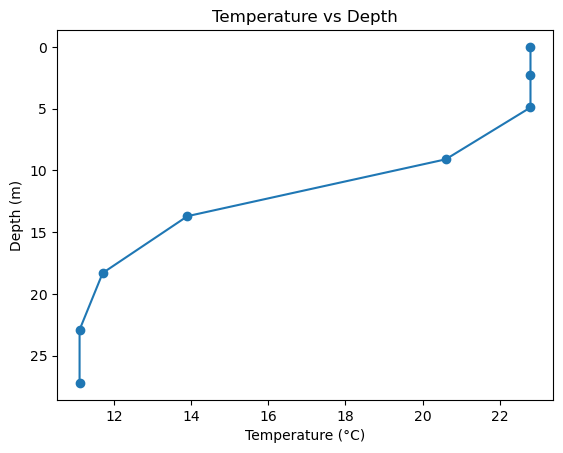

In [3]:
# rotate the plot below to make the depth axis vertical but keep z as the independent variable
import matplotlib.pyplot as plt
plt.plot(T, z, 'o-')  # plot with depth on vertical axis
plt.xlabel('Temperature (°C)')
plt.ylabel('Depth (m)')
plt.title('Temperature vs Depth')
plt.gca().invert_yaxis()  # Depth increases downward
plt.show()


Let us keep the depth along the horizontal to be consistent with the independent variable to be along x

## Fit a curve to interpolate the values

Estimated temperature at 15 m depth: 13.278260869565218 °C


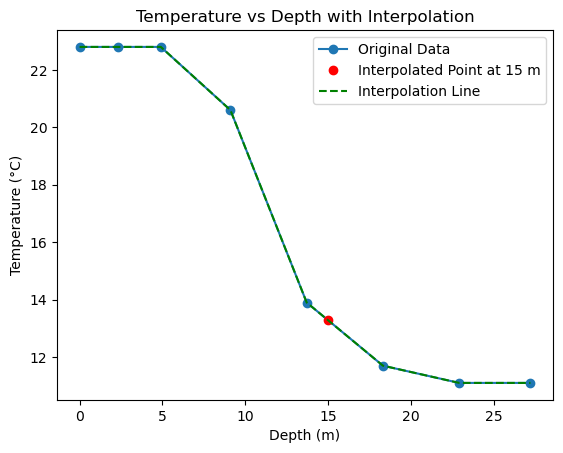

In [4]:
# apply a linear interpolation to estimate the temperature at 15 m depth
from scipy.interpolate import interp1d
interp_func = interp1d(z, T)

# estimate temperature at 15 m depth
temp_15m = interp_func(15)
print(f"Estimated temperature at 15 m depth: {temp_15m} °C")
# plot the original data points and the interpolated point
plt.plot(z, T, 'o-', label='Original Data')
plt.plot(15, temp_15m, 'ro', label='Interpolated Point at 15 m')
plt.plot(z, interp_func(z), 'g--', label='Interpolation Line')
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Depth with Interpolation')
plt.legend()
plt.show()


Estimated temperature at 15 m depth (Cubic Spline): 12.76250900312552 °C


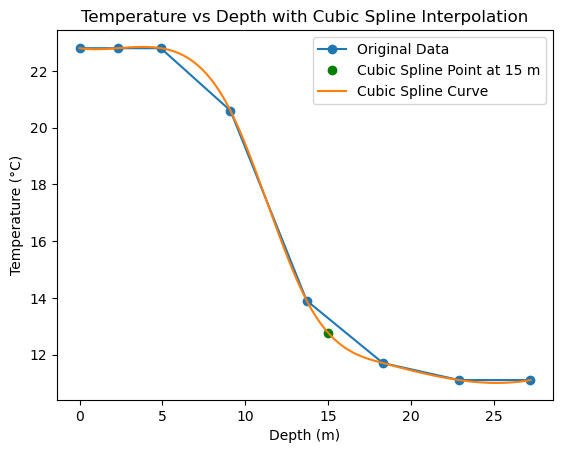

In [5]:
# do the same with a cubic spline interpolation
from scipy.interpolate import CubicSpline
cs = CubicSpline(z, T)  
temp_15m_cs = cs(15)
print(f"Estimated temperature at 15 m depth (Cubic Spline): {temp_15m_cs} °C")

# add in the plot the cubic spline interpolation curve
z_fine = np.linspace(0, 27.2, 100)
T_cs_fine = cs(z_fine)


# plot the original data points and the cubic spline interpolated point
plt.plot(z, T, 'o-', label='Original Data')
plt.plot(15, temp_15m_cs, 'go', label='Cubic Spline Point at 15 m')
plt.plot(z_fine, T_cs_fine, '-', label='Cubic Spline Curve')
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')  
plt.title('Temperature vs Depth with Cubic Spline Interpolation')
plt.legend()
plt.show()


## Vandermonde
### Example 17.1 Python book   

In [6]:
import numpy as np

# Given data points
x = np.array([300, 400, 500])
y = np.array([0.616, 0.525, 0.457])

# Construct Vandermonde matrix for a quadratic polynomial (degree 2)
V = np.vander(x, 3)

# Solve for polynomial coefficients
coeffs = np.linalg.solve(V, y)

print("Polynomial coefficients (a, b, c) for ax^2 + bx + c:")
print(coeffs)

Polynomial coefficients (a, b, c) for ax^2 + bx + c:
[ 1.150e-06 -1.715e-03  1.027e+00]


In [7]:
# print the vandermonde matrix
print("\nVandermonde matrix:")
print(V)


Vandermonde matrix:
[[ 90000    300      1]
 [160000    400      1]
 [250000    500      1]]


In [8]:
# Evaluate the polynomial at a new point, e.g., x = 350
x_new = 350
y_new = np.polyval(coeffs[::1], x_new)
print(f"Estimated value at x = {x_new}: {y_new}")

Estimated value at x = 350: 0.567625


In [9]:
# what is the condition number of the vandermonde matrix
cond_number = np.linalg.cond(V)
print(f"Condition number of the Vandermonde matrix: {cond_number}")


Condition number of the Vandermonde matrix: 5893156.794923048


In [10]:
# results above seems wrong. Calculate the polynomial coefficients directly
coeffs_direct = np.polyfit(x, y, 2)
print("Polynomial coefficients (a, b, c) for ax^2 + bx + c (direct calculation):")
print(coeffs_direct)

Polynomial coefficients (a, b, c) for ax^2 + bx + c (direct calculation):
[ 1.150e-06 -1.715e-03  1.027e+00]


In [11]:
a = coeffs_direct[0]
b = coeffs_direct[1]
c = coeffs_direct[2]
a*x_new**2 + b*x_new + c

np.float64(0.567625)

In [12]:
# use polyval to evaluate the polynomial at the new point
y_new_direct = np.polyval(coeffs_direct[::1], x_new)
print(f"Estimated value at x = {x_new} (direct calculation): {y_new_direct}")


Estimated value at x = 350 (direct calculation): 0.5676249999999999


### Newton difference interpolation

In [13]:
import numpy as np

def Newtint(x,y,xx):
    """
    Newtint: Newton interpolating polynomial
    Uses an (n-1)th-order Newton interpolating polynomial
    based on n data pairs to return a value of the
    dependent variable, yint, at a given value of the
    independent variable, xx.
    Input:
        x = array of independent variable values
        y = array of dependent variable values
        xx = value of independent variable at which
             the interpolation is calculated
    Output:
        yint = interpolated value of the dependent variable
    """
    # compute the finite divided differences in the 
    # form of a difference table
    n = len(x)
    if len(y) != n:
        return 'x and y must be of same length'
    b = np.zeros((n,n))
    # assign the dependent variables to the first column of b
    b[:,0] = np.transpose(y)
    for j in range(1,n):
        for i in range(n-j):
            b[i,j] = (b[i+1,j-1]-b[i,j-1])/(x[i+j]-x[i])
    # use the finite divided differences to interpolate
    xt = 1
    yint = b[0,0]
    for j in range(n-1):
        xt = xt * (xx - x[j])
        yint = yint + b[0,j+1]*xt
    return yint



In [14]:
# Approximate the logarithm of a number using Newton's interpolation
x = np.array([1., 4., 6., 5.])
y = np.log(x)
yi = Newtint(x, y, 2.)
print(yi)
# Calculate the logarithm directly for comparison and print the relative error in percentage
log_direct = np.log(2.)
print(f"Direct log(2) value: {log_direct}")
print(f"Error in interpolation: {yi - log_direct}")
print(f"Relative error in interpolation: {(yi - log_direct) / log_direct * 100:.2f}%")


0.6287685789084135
Direct log(2) value: 0.6931471805599453
Error in interpolation: -0.06437860165153175
Relative error in interpolation: -9.29%


In [15]:
# Example interpolation with Vandermonde matrix. Calculate the error just as above
# Create the Vandermonde matrix and solve for polynomial coefficients
x = np.array([1., 4., 6., 5.])
y = np.log(x)
n = len(x)
A = np.vander(x, N=n)
coeffs_vander = np.linalg.solve(A, y)

# Use polyval to evaluate the polynomial at the new point
y_new_vander = np.polyval(coeffs_vander, 2.)
print(f"Estimated value at x = 2 (Vandermonde): {y_new_vander}")
# Calculate the logarithm directly for comparison
log_direct_vander = np.log(2.)
print(f"Direct log(2) value (Vandermonde): {log_direct_vander}")
print(f"Error in interpolation (Vandermonde): {y_new_vander - log_direct_vander}")
print(f"Relative error in interpolation (Vandermonde): {(y_new_vander - log_direct_vander) / log_direct_vander * 100:.2f}%")

Estimated value at x = 2 (Vandermonde): 0.6287685789084143
Direct log(2) value (Vandermonde): 0.6931471805599453
Error in interpolation (Vandermonde): -0.06437860165153098
Relative error in interpolation (Vandermonde): -9.29%


In [16]:
# Repeat the comparison above with Newton and Vandermonde methods but using only 3 points
# Print the relative error in both cases (Newton and Vandermonde)
# Example interpolation with Vandermonde matrix. Calcualate the error just as above
# Create the Vandermonde matrix and solve for polynomial coefficients
x = np.array([1., 4., 6.])
y = np.log(x)
n = len(x)
A = np.vander(x, N=n)
coeffs_vander = np.linalg.solve(A, y)       

# Use polyval to evaluate the polynomial at the new point
y_new_vander = np.polyval(coeffs_vander, 2.)
print(f"Estimated value at x = 2 (Vandermonde with 3 points): {y_new_vander}")
# Calculate the logarithm directly for comparison
log_direct_vander = np.log(2.)
print(f"Direct log(2) value (Vandermonde with 3 points): {log_direct_vander}")
print(f"Error in interpolation (Vandermonde with 3 points): {y_new_vander - log_direct_vander}")
print(f"Relative error in interpolation (Vandermonde with 3 points): {(y_new_vander - log_direct_vander) / log_direct_vander * 100:.2f}%")      

Estimated value at x = 2 (Vandermonde with 3 points): 0.5658443469009825
Direct log(2) value (Vandermonde with 3 points): 0.6931471805599453
Error in interpolation (Vandermonde with 3 points): -0.12730283365896278
Relative error in interpolation (Vandermonde with 3 points): -18.37%


In [17]:
# Now with Newton's method using 3 points
yi_newt = Newtint(x, y, 2.)
print(f"Estimated value at x = 2 (Newton with 3 points): {yi_newt}")
# Calculate the logarithm directly for comparison
log_direct_newt = np.log(2.)
print(f"Direct log(2) value (Newton with 3 points): {log_direct_newt}")
print(f"Error in interpolation (Newton with 3 points): {yi_newt - log_direct_newt}")
print(f"Relative error in interpolation (Newton with 3 points): {(yi_newt - log_direct_newt) / log_direct_newt * 100:.2f}%")

Estimated value at x = 2 (Newton with 3 points): 0.5658443469009827
Direct log(2) value (Newton with 3 points): 0.6931471805599453
Error in interpolation (Newton with 3 points): -0.12730283365896256
Relative error in interpolation (Newton with 3 points): -18.37%


## Using Newtinp for the depth/Temp example

In [18]:
import numpy as np
data = np.array([
0,22.8,
2.3,22.8,
4.9,22.8,
9.1,20.6,
13.7,13.9,
18.3,11.7,
22.9,11.1,
27.2,11.1]).T
z=data[0::2]
T=data[1::2]
t_15 = Newtint(z, T, 15)
print(f"Estimated temperature at 15 m depth (Newton): {t_15} °C")
from scipy.interpolate import CubicSpline
cs = CubicSpline(z, T)  
t_15_cs = cs(15)
print(f"Estimated temperature at 15 m depth (Cubic Spline): {t_15_cs} °C")
t_15_lin = np.interp(15, z, T)
print(f"Estimated temperature at 15 m depth (Linear Interpolation): {t_15_lin} °C")

Estimated temperature at 15 m depth (Newton): 12.51230518188828 °C
Estimated temperature at 15 m depth (Cubic Spline): 12.76250900312552 °C
Estimated temperature at 15 m depth (Linear Interpolation): 13.278260869565218 °C


## Lagrange Interpolation

In [19]:
import numpy as np

def Lagrange(x,y,xx):
    """
    Lagrange interpolating polynomial
    Uses an (n-1)th-order Lagrange interpolating polynomial
    based on n data pairs to return a value of the
    dependent variable, yint, at a given value of the
    independent variable, xx.
    Input:
        x = array of independent variable values
        y = array of dependent variable values
        xx = value of independent variable at which
             the interpolation is calculated
    Output:
        yint = interpolated value of the dependent variable
    """
    n = len(x)
    if len(y) != n:
        return 'x and y must be of same length'
    s = 0
    for i in range(n):
        product = y[i]
        for j in range(n):
            if i != j:
                product = product * (xx - x[j])/(x[i]-x[j])
        s = s + product
    yint = s
    return yint


In [20]:
# Example interpolation with Lagrange polynomial
# create a table with Temperature and density values
# and interpolate at a given temperature
# This is an example similar to the one in the book with Python syntax
T = np.array([-40., 0., 20., 50.])
rho = np.array([1.52, 1.29, 1.2, 1.09])
rhoint = Lagrange(T,rho,15.)
print(rhoint)

1.2211284722222222


In [21]:
import numpy as np

def cspline(x,y,xx):
    """
    Cubic Spline Interpolation with Natural End Conditions
    input:
        x = array of independent variable values
        y = array of dependent variable values
        xx = input value for interpolation
    output:
        yy = interpolated value of y
    """
    n = len(x)
    if len(y) != n: return 'input arrays must be the same length'
    if xx < x[0] or xx > x[n-1]: return 'input value out of range of table'
    h = np.zeros((n-1))
    for i in range(n-1):
        h[i] = x[i+1] - x[i]
    df = np.zeros((n-1))
    for i in range(n-1):
        df[i] = (y[i+1]-y[i])/h[i]
    A = np.zeros((n,n))
    A[0,0] = 1 ; A[n-1,n-1] = 1
    for i in range(1,n-1):
        A[i,i-1] = h[i-1]
        A[i,i] = 2*(h[i-1] + h[i])
        A[i,i+1] = h[i]
    const = np.zeros((n))
    for i in range(1,n-1):
        const[i] = 3*(df[i]-df[i-1])
    c = np.linalg.solve(A,const)
    b = np.zeros((n-1))
    for i in range(n-1):
        b[i] = (y[i+1]-y[i])/h[i]-h[i]/3*(2*c[i]+c[i+1])
    d = np.zeros((n-1))
    for i in range(n-1):
        d[i] = (c[i+1]-c[i])/3/h[i]
    for i in range(n):
        if xx == x[i]:  # check for an exact match
            return y[i]
        elif x[i] > xx:  # check for upper interval
            i2 = i-1
            break
    yy = y[i2] + b[i2]*(xx-x[i2]) + c[i2]*(xx-x[i2])**2 + d[i2]*(xx-x[i2])**3
    return yy



In [22]:
T = np.array([-40.,   0.,  20., 50., 100., 150., 200., 250.,
              300., 400., 500.])
rho = np.array([1.52,  1.29,  1.20,  1.09,  0.946, 0.835,
                0.746, 0.675, 0.616, 0.525, 0.457])
    
Tx = 350.
rhox = cspline(T,rho,Tx)
print(rhox)


0.5665375927793199


In [23]:
import numpy as np
from scipy.interpolate import CubicSpline

data = np.array([
0,22.8,
2.3,22.8,
4.9,22.8,
9.1,20.6,
13.7,13.9,
18.3,11.7,
22.9,11.1,
27.2,11.1]).T
z=data[0::2]
T=data[1::2]
t_15_lin = np.interp(15, z, T)
t_15_n = Newtint(z, T, 15)
t_15_l = Lagrange(z, T, 15)
cs = CubicSpline(z, T)  
t_15_cs = cs(15)
print(f"Estimated temperature at 15 m depth (Linear Interpolation): {t_15_lin} °C")
print(f"Estimated temperature at 15 m depth (Newton): {t_15_n} °C")
print(f"Estimated temperature at 15 m depth (Lagrange): {t_15_l} °C")
print(f"Estimated temperature at 15 m depth (Cubic Spline): {t_15_cs} °C")

Estimated temperature at 15 m depth (Linear Interpolation): 13.278260869565218 °C
Estimated temperature at 15 m depth (Newton): 12.51230518188828 °C
Estimated temperature at 15 m depth (Lagrange): 12.51230518188828 °C
Estimated temperature at 15 m depth (Cubic Spline): 12.76250900312552 °C


In [24]:
import numpy as np

data = np.array([
0,22.8,
2.3,22.8,
4.9,22.8,
9.1,20.6,
13.7,13.9,
18.3,11.7,
22.9,11.1,
27.2,11.1]).T
z=data[0::2]
T=data[1::2]
t_15_lin = np.interp(15, z, T)
t_15_n = Newtint(z, T, 15)
t_15_l = Lagrange(z, T, 15)
t_15_cs = cspline(z, T, 15)
print(f"Estimated temperature at 15 m depth (Linear Interpolation): {t_15_lin} °C")
print(f"Estimated temperature at 15 m depth (Newton): {t_15_n} °C")
print(f"Estimated temperature at 15 m depth (Lagrange): {t_15_l} °C")
print(f"Estimated temperature at 15 m depth (Cubic Spline): {t_15_cs} °C")

Estimated temperature at 15 m depth (Linear Interpolation): 13.278260869565218 °C
Estimated temperature at 15 m depth (Newton): 12.51230518188828 °C
Estimated temperature at 15 m depth (Lagrange): 12.51230518188828 °C
Estimated temperature at 15 m depth (Cubic Spline): 12.765189902433685 °C


## Example of Newton divide differences with and without reordering.
First exact arithmetic = equal results

In [3]:
import numpy as np

def divided_differences(x, y):
    """Compute Newton divided-difference coefficients."""
    x = np.asarray(x, dtype=float)
    coef = np.asarray(y, dtype=float).copy()
    n = len(x)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            coef[i] = (coef[i] - coef[i-1]) / (x[i] - x[i-j])
    return coef

def newton_eval(x_nodes, coef, x):
    """Evaluate Newton polynomial at x."""
    p = coef[-1]
    for k in range(len(coef)-2, -1, -1):
        p = p * (x - x_nodes[k]) + coef[k]
    return p

In [4]:
# ----------------------------------------------------
# Function and data
# ----------------------------------------------------
f = np.exp
x_data = np.array([-1.0, 0.0, 1.0, 2.0])
y_data = f(x_data)

x_star = 0.1
true_value = f(x_star)

# ----------------------------------------------------
# Case A: BAD ordering (far points first)
# ----------------------------------------------------
order_bad = np.array([2.0, 1.0, 0.0, -1.0])
y_bad = f(order_bad)

coef_bad = divided_differences(order_bad, y_bad)
p_bad = newton_eval(order_bad, coef_bad, x_star)

# ----------------------------------------------------
# Case B: GOOD ordering (closest points first)
# ----------------------------------------------------
order_good = np.array([0.0, 1.0, -1.0, 2.0])
y_good = f(order_good)

coef_good = divided_differences(order_good, y_good)
p_good = newton_eval(order_good, coef_good, x_star)

# ----------------------------------------------------
# Results
# ----------------------------------------------------
print(f"True value        : {true_value:.10f}\n")

print("Bad ordering:")
print(f"  Newton approx   : {p_bad:.10f}")
print(f"  Absolute error  : {abs(p_bad - true_value):.2e}\n")

print("Good ordering:")
print(f"  Newton approx   : {p_good:.10f}")
print(f"  Absolute error  : {abs(p_good - true_value):.2e}")


True value        : 1.1051709181

Bad ordering:
  Newton approx   : 1.0921564614
  Absolute error  : 1.30e-02

Good ordering:
  Newton approx   : 1.0921564614
  Absolute error  : 1.30e-02


In [5]:

# ----------------------------------------------------
# Data: many points, but we'll use only m of them
# ----------------------------------------------------
f = np.exp
x_data = np.linspace(-2, 2, 21)        # 21 points
y_data = f(x_data)

x_star = 0.15
true_value = f(x_star)

m = 6  # use only 6 points => degree-5 polynomial

# Nearest-first ordering, then take first m
idx_near = np.argsort(np.abs(x_data - x_star))
x_near = x_data[idx_near][:m]
y_near = y_data[idx_near][:m]

# Farthest-first ordering, then take first m
idx_far = np.argsort(np.abs(x_data - x_star))[::-1]
x_far = x_data[idx_far][:m]
y_far = y_data[idx_far][:m]

# Build and evaluate
coef_near = divided_differences(x_near, y_near)
p_near = newton_eval(x_near, coef_near, x_star)

coef_far = divided_differences(x_far, y_far)
p_far = newton_eval(x_far, coef_far, x_star)

print(f"x* = {x_star}")
print(f"true f(x*)      = {true_value:.12e}\n")

print("Using m nearest points:")
print("x_nodes =", np.round(x_near, 3))
print(f"P(x*)   = {p_near:.12e}")
print(f"abs err = {abs(p_near-true_value):.3e}\n")

print("Using m farthest points:")
print("x_nodes =", np.round(x_far, 3))
print(f"P(x*)   = {p_far:.12e}")
print(f"abs err = {abs(p_far-true_value):.3e}")


x* = 0.15
true f(x*)      = 1.161834242728e+00

Using m nearest points:
x_nodes = [ 0.2  0.   0.4 -0.2  0.6 -0.4]
P(x*)   = 1.161834495403e+00
abs err = 2.527e-07

Using m farthest points:
x_nodes = [-2.  -1.8  2.  -1.6  1.8 -1.4]
P(x*)   = 1.123874786286e+00
abs err = 3.796e-02
